# 中国上市公司数量年度统计 (EDA)

### 📊 分析背景与目标
基于前期完成的 A 股全量上市公司数据采集与清洗工作，本项目旨在对中国资本市场进行深度的探索性数据分析（EDA）。

### 💡 核心分析维度 (包含四大视角)
1. **重大政策节点的事件研究（折线图）**：将各年度 IPO 数量趋势与重大政策节点叠加，讲述政策背后的故事。
2. **各板块年度新增上市结构（堆叠柱状图）**：透视每年新增上市公司中，主板、创业板、科创板及北交所的占比变化与扩容主力。
3. **各板块“上市年龄结构”（箱线图/密度图）**：计算各公司的上市年龄，对比不同板块的历史厚度与“老龄化”程度差异。
4. **整体及各交易所行业分布画像（条形图/饼图）**：展现 A 股整体行业基石，并对比沪、深、北三大交易所在行业聚集上的定位差异。

### 🎯 提示词：
- 请编写一个数据分析与绘图脚本。读取 data_clean 中的清洗数据，分析并生成以下 4 个维度的图表。
- 要求（关键）： 所有图表必须解决跨平台中文字体乱码问题，并在 plt.show() 前以 300dpi 自动保存到 output 文件夹中：
1. 政策事件折线图：统计历年新增上市数量，并在 2006、2009、2013、2019、2021 等关键年份添加带文字说明的红色虚线（标注注册制、开市等重大政策）。
2. 板块扩容堆叠图：按‘上市年份’和‘交易所-板块’绘制每年新增上市公司数量的堆叠柱状图。
3. 上市年龄结构图：计算各公司的上市年龄，画一张 1x2 的子图，左边为各板块年龄箱线图（按中位数排序），右边为核密度分布图。
4. 行业画像分布图：画一张全市场 Top 15 行业的水平条形图；再画一张 1x3 的子图，分别展示沪、深、北三大交易所前 5 大行业的占比饼图。”

### 📂 环境配置与数据加载

In [ ]:
# 若没有安装这个库，需先安装
# pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# --- 🚨 针对 Mac 系统的中文字体配置 ---
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
sns.set_theme(style="whitegrid", font="Arial Unicode MS", font_scale=1.2) 

# --- 🚨 核心修复：动态锚定当前 Notebook 所在的绝对路径 ---
# 获取当前脚本的绝对路径目录
current_dir = os.path.abspath('')

# 动态拼接完整的 data_clean 和 output 绝对路径
file_dir = os.path.join(current_dir, "data_clean")
output_dir = os.path.join(current_dir, "output")

# 确保 output 文件夹建在当前目录下
os.makedirs(output_dir, exist_ok=True)

# --- 数据读取与预处理 ---
file_name = "china_listed_official_data_patched.csv"
file_path = os.path.join(file_dir, file_name)

print(f"🔍 正在尝试读取绝对路径: {file_path}")

# 加入容错拦截：如果路径不对，给予明确提示
if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"找不到文件！\n"
        f"请检查:\n"
        f"1. 'data_clean' 文件夹是否真的在这个目录下: {current_dir}\n"
        f"2. 文件名是否为 '{file_name}'"
    )

df = pd.read_csv(file_path, dtype={'证券代码': str})

# 时间类型转换
df['上市日期'] = pd.to_datetime(df['上市日期'], errors='coerce')
df = df.dropna(subset=['上市日期']).copy()

df['上市年份'] = df['上市日期'].dt.year

current_date = pd.to_datetime('today')
df['上市年龄'] = (current_date - df['上市日期']).dt.days / 365.25

print(f"✅ 数据读取成功！共加载 {len(df)} 家上市公司的有效数据。")
display(df.head())

🔍 正在尝试读取绝对路径: /Users/lln/Documents/个人信息/考研/中大课程资料/数据分析与经济决策课/作业/第5组作业/data_clean/china_listed_official_data_patched.csv
✅ 数据读取成功！共加载 5489 家上市公司的有效数据。


,证券代码,证券名称,交易所名称,上市日期,上市板块,所属行业,上市年份,上市年龄
0,000001.SZ,平安银行,深圳证券交易所,1991-04-03,主板,工业,1991,34.951403
1,000002.SZ,万 科Ａ,深圳证券交易所,1991-01-29,主板,房地产,1991,35.126626
2,000004.SZ,*ST国华,深圳证券交易所,1990-12-01,主板,信息技术,1990,35.288159
3,000006.SZ,深振业Ａ,深圳证券交易所,1992-04-27,主板,房地产,1992,33.883641
4,000007.SZ,全新好,深圳证券交易所,1992-04-13,主板,房地产,1992,33.921971


#### 📝 分析结论
在这一步中，我们成功加载了经过 `01_data_clean.ipynb` 清洗打补丁后的全量数据集。
为了支撑后续的深度分析，我们基于 `上市日期` 派生出了两个重要的新特征：
* **`上市年份`**：用于按年度统计首发上市（IPO）的数量规模。
* **`上市年龄`**：精确计算了每家公司从敲钟上市到今天所经历的年数，为后续的板块“老龄化”程度分析做好了数据铺垫。

## 分析维度一：重大政策节点与 A 股 IPO 历史洪流（事件研究）

中国资本市场的发展史，就是一部制度改革史。单纯的年度上市数量折线图只是一串冷冰冰的数字，我们需要精准标注每一个关键政策节点，来看看政策是如何直接影响市场扩容节奏的。

📸 图片已保存: output/1_IPO趋势与政策节点折线图.png


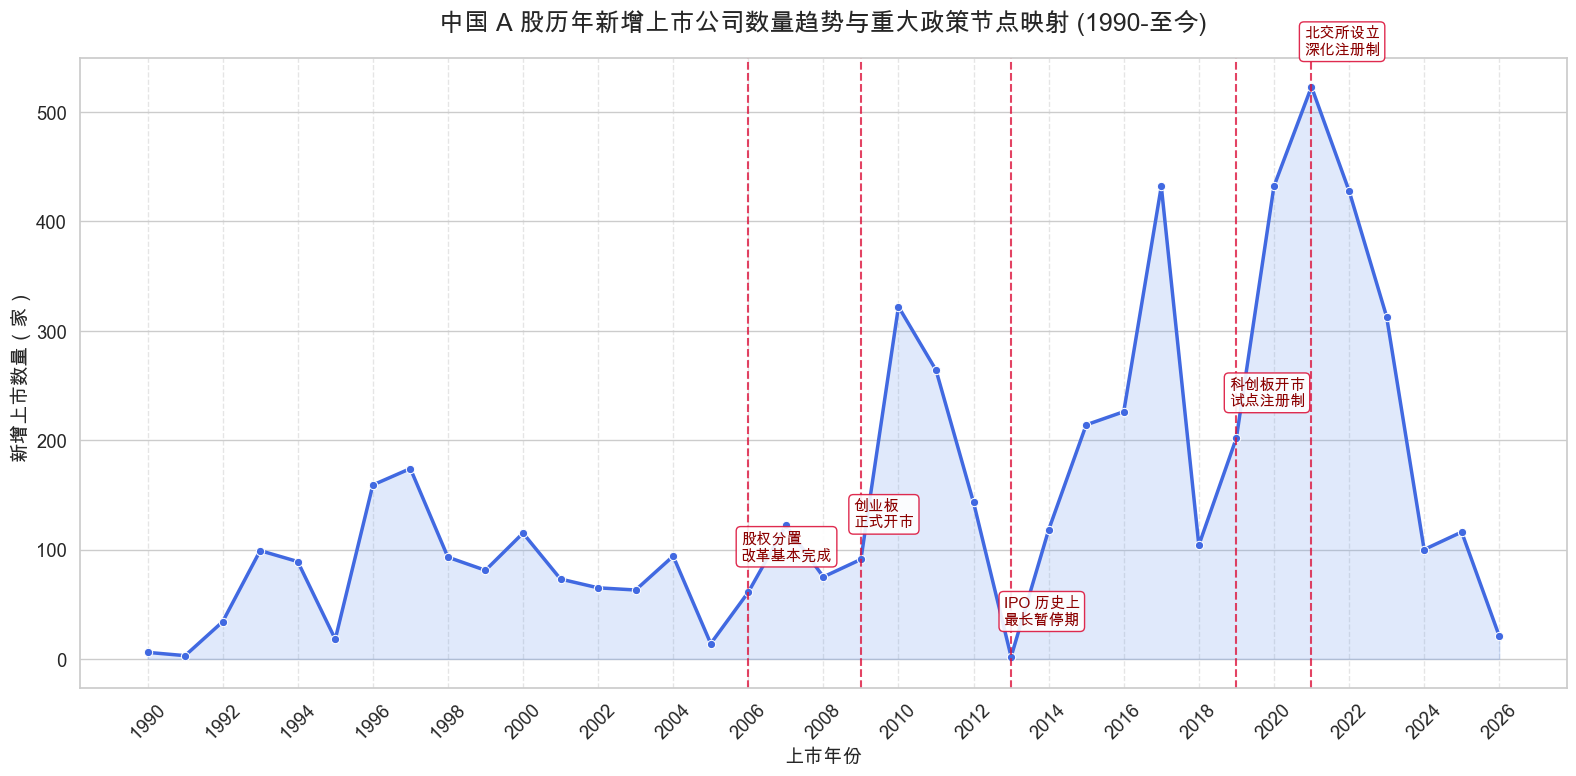

In [ ]:
# 1. 统计每年新上市的公司数量
yearly_counts = df.groupby('上市年份').size().reset_index(name='新增上市数量')

# 为了图表美观，我们截取 1990 年以来的数据
yearly_counts = yearly_counts[yearly_counts['上市年份'] >= 1990]

# 2. 创建画布并绘制折线图和面积图
plt.figure(figsize=(16, 8))
sns.lineplot(data=yearly_counts, x='上市年份', y='新增上市数量', color='royalblue', linewidth=2.5, marker='o', markersize=6)
plt.fill_between(yearly_counts['上市年份'], yearly_counts['新增上市数量'], color='cornflowerblue', alpha=0.2)

# 3. 核心：标注重大历史/政策节点
events = {
    2006: "股权分置\n改革基本完成",
    2009: "创业板\n正式开市",
    2013: "IPO 历史上\n最长暂停期",
    2019: "科创板开市\n试点注册制",
    2021: "北交所设立\n深化注册制"
}

# 遍历字典，添加垂直参考线和文本注释
for year, event_text in events.items():
    plt.axvline(x=year, color='crimson', linestyle='--', linewidth=1.5, alpha=0.8)
    # 根据年份对应的数量确定 y 轴文字高度，防止文字重叠
    y_pos = yearly_counts[yearly_counts['上市年份'] == year]['新增上市数量'].values
    y_val = y_pos[0] if len(y_pos) > 0 else 200
    
    plt.text(year - 0.2, y_val + 30, event_text, color='darkred', fontsize=11, 
             bbox=dict(facecolor='white', edgecolor='crimson', boxstyle='round,pad=0.3', alpha=0.9))

# 4. 图表细节美化
plt.title('中国 A 股历年新增上市公司数量趋势与重大政策节点映射 (1990-至今)', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('上市年份', fontsize=14)
plt.ylabel('新增上市数量（家）', fontsize=14)
plt.xticks(range(1990, int(df['上市年份'].max()) + 1, 2), rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

# --- 保存图片 ---
out_path = os.path.join("output", "1_IPO趋势与政策节点折线图.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"📸 图片已保存: {out_path}")

plt.show()

#### 📝 分析结论：图形背后的改革故事
通过将政策节点叠加在数量趋势图上，我们可以清晰地读出 A 股市场的脉搏：
* **2006年（股权分置改革）**：解决了历史遗留的流通股与非流通股问题，为后续（尤其是2010年前后）的上市高峰扫清了制度性障碍。
* **2009年（创业板开市）**：直接催生了2010-2011年的中小企业上市浪潮。
* **2013年（IPO 暂停）**：图表中出现了一个极度明显的“深坑”，这是A股历史上第8次、也是历时最长的一次 IPO 暂停，导致当年新增数量几乎归零。
* **2019-2021年（注册制改革爆发期）**：伴随着科创板的开市和北交所的设立，A 股迎来了全面注册制改革，上市效率大幅提升，我们在图表右侧看到了连续三年（2020-2022）的史诗级扩容高峰，年均新增直逼 400-500 家。

## 分析维度二：各板块年度新增上市规模构成（堆叠柱状图）
除了总量的起伏，我们还需要透视每年新增公司的**结构**。通过交叉表和堆叠图，我们可以清晰地看到不同历史时期，哪个交易所、哪个板块是扩容的绝对主力。

=== 近 10 年各交易所/板块新增上市公司数量分布表 ===


交易所_板块,上海-主板,上海-科创板,北京-北交所,深圳-主板,深圳-创业板
上市年份,,,,,
2017,210,0,0,82,140
2018,57,0,0,19,28
2019,55,70,0,26,51
2020,90,143,38,54,107
2021,88,162,40,34,199
2022,31,124,83,40,150
2023,36,67,77,23,110
2024,17,15,23,7,38
2025,23,19,26,15,33


📸 图片已保存: output/2_新增上市结构堆叠图.png


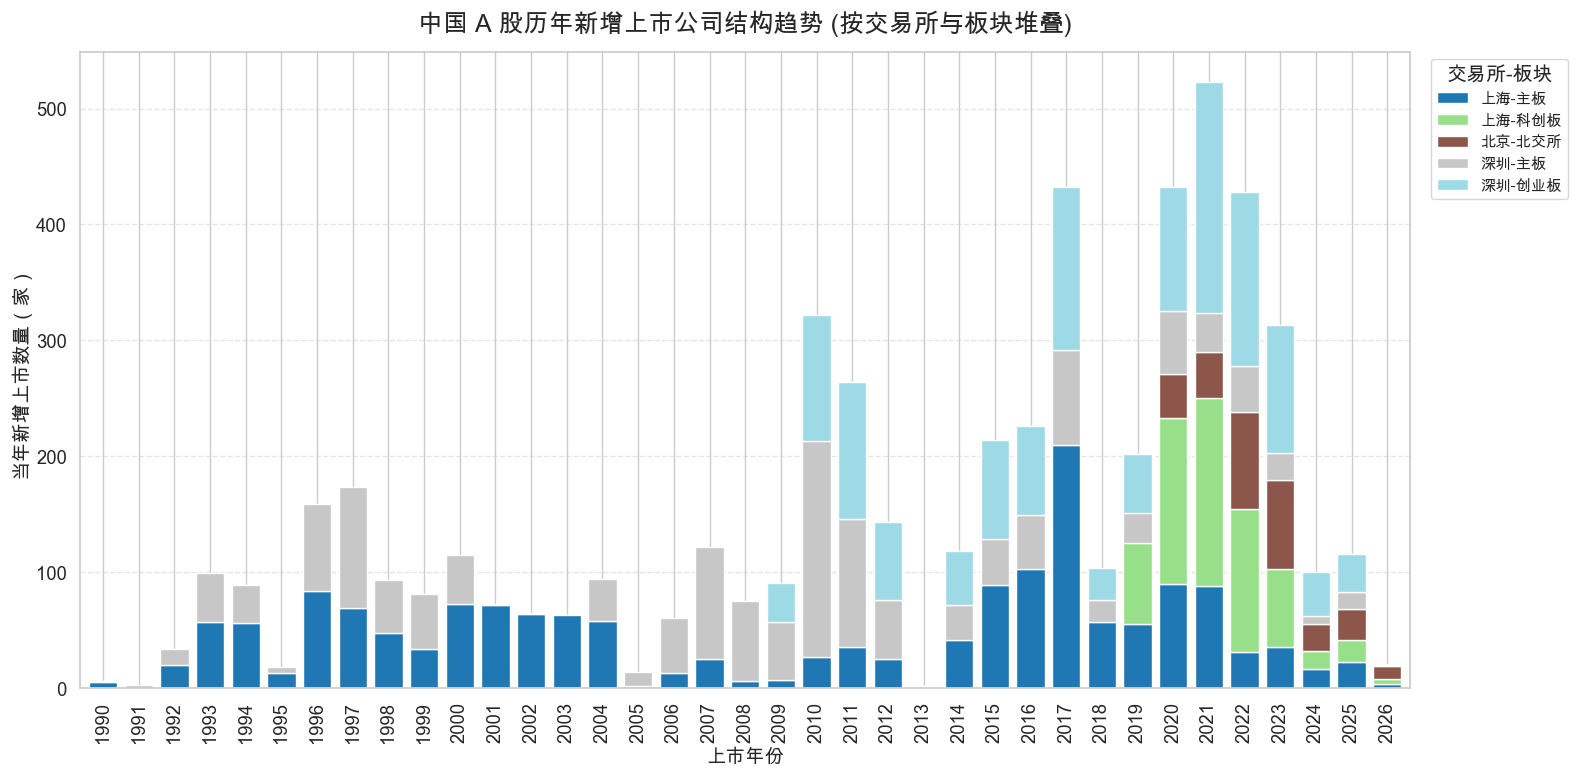

In [ ]:
# 1. 构造“交易所-板块”联合字段
df['交易所_板块'] = df['交易所名称'].str.replace('证券交易所', '') + '-' + df['上市板块']

# 2. 生成交叉透视表 (统计每年各板块的新增数量)
yearly_board_counts = pd.crosstab(df['上市年份'], df['交易所_板块'])
yearly_board_counts = yearly_board_counts[yearly_board_counts.index >= 1990]

# 3. 打印控制台表格 (近 10 年数据预览)
print("=== 近 10 年各交易所/板块新增上市公司数量分布表 ===")
display(yearly_board_counts.tail(10))

# 4. 绘制堆叠柱状图
yearly_board_counts.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='tab20', width=0.8)

plt.title('中国 A 股历年新增上市公司结构趋势 (按交易所与板块堆叠)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('上市年份', fontsize=14)
plt.ylabel('当年新增上市数量（家）', fontsize=14)
plt.legend(title='交易所-板块', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# --- 保存图片 ---
out_path = os.path.join("output", "2_新增上市结构堆叠图.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"📸 图片已保存: {out_path}")

plt.show()

#### 📝 分析结论：A 股扩容主力的时代变迁
堆叠图清晰地展现了中国资本市场多层次建设的成果：
* **2010年之前**：上交所主板和深交所主板是绝对的基石，几乎占据了所有的上市名额。
* **2010-2017年**：深交所创业板异军突起，占据了半壁江山，成为中小企业上市的首选。
* **2019年之后**：随着注册制改革，**上海-科创板** 和 **北京-北交所** 构成了近几年顶部最明显的色块，A股市场真正形成了“沪深北”三足鼎立、各有侧重的多层次资本市场格局。

## 分析维度三：各板块的“上市年龄结构”与老龄化程度透视

由于各板块设立的时间先后不同，其上市公司的“年龄分布”也呈现出极大的差异。我们将通过计算每家公司到今天的“上市年龄”，利用**箱线图（Boxplot）**和**核密度图（KDE）**，直观感受各板块的历史厚度。

📸 图片已保存: output/3_上市年龄结构对比图.png


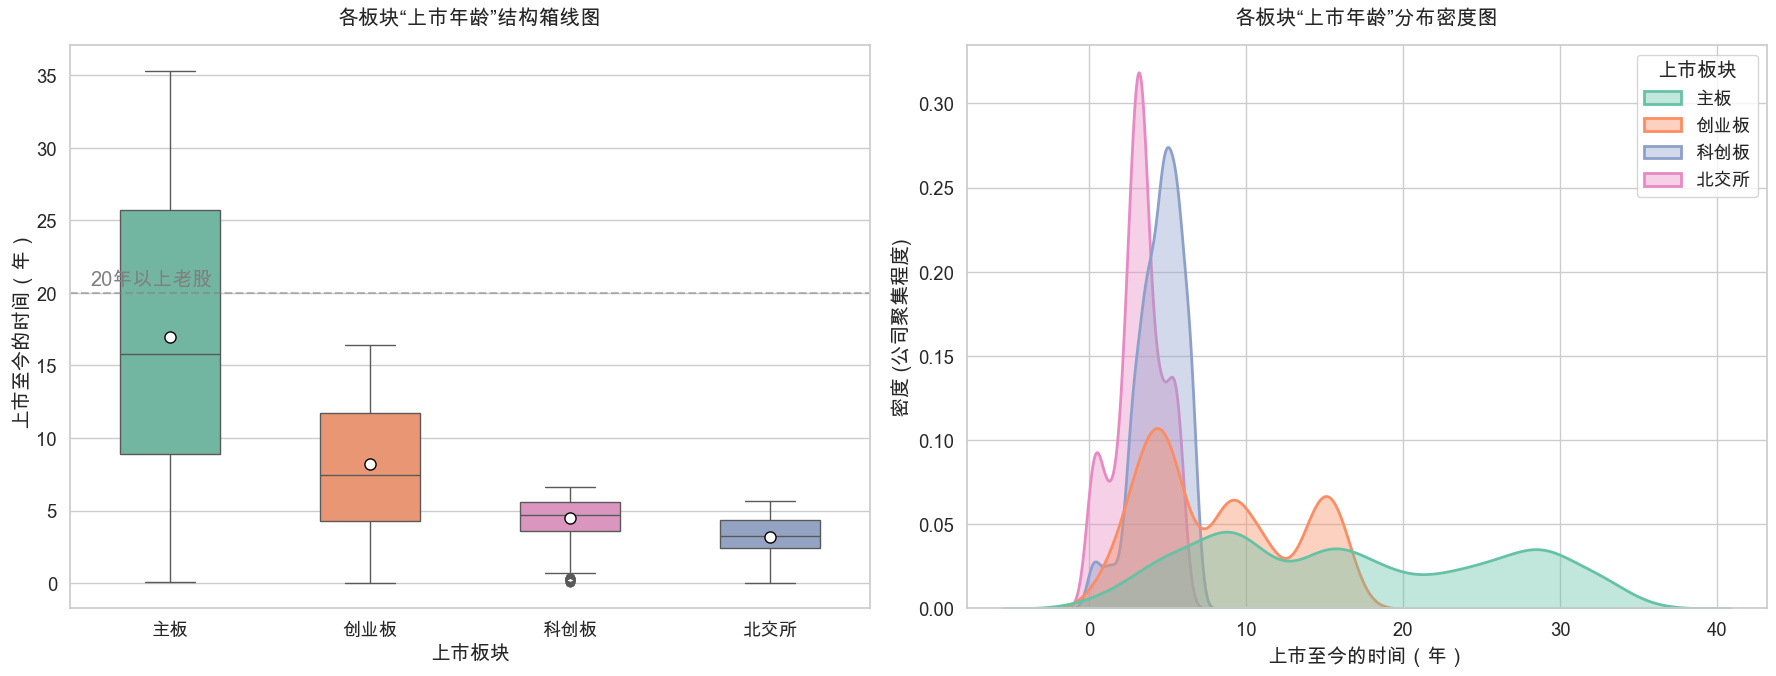

In [ ]:
# === 维度三：各板块的“上市年龄结构”与老龄化透视 ===

# 剔除未分类或其他板块的杂乱数据
board_df = df[df['上市板块'].isin(['主板', '创业板', '科创板', '北交所'])].copy()

# 按平均上市年龄对板块进行排序
board_order = board_df.groupby('上市板块')['上市年龄'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 图 1：各板块上市年龄箱线图 ---
# 🚨 核心修复：添加 hue='上市板块' 和 legend=False
sns.boxplot(
    data=board_df, 
    x='上市板块', 
    y='上市年龄', 
    order=board_order, 
    hue='上市板块',       # <--- 修复点 1：将 x 轴变量赋给 hue
    legend=False,         # <--- 修复点 2：关闭图例
    palette='Set2', 
    width=0.5, 
    ax=axes[0], 
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": 8}
)
axes[0].set_title('各板块“上市年龄”结构箱线图', fontsize=15, fontweight='bold', pad=15)
axes[0].set_ylabel('上市至今的时间（年）')
axes[0].set_xlabel('上市板块')
axes[0].axhline(y=20, color='gray', linestyle='--', alpha=0.5)
axes[0].text(-0.4, 20.5, '20年以上老股', color='gray')

# --- 图 2：各板块上市年龄核密度分布图 (KDE) ---
sns.kdeplot(
    data=board_df, 
    x='上市年龄', 
    hue='上市板块', 
    hue_order=board_order,
    fill=True, 
    common_norm=False, 
    palette='Set2', 
    alpha=0.4, 
    linewidth=2, 
    ax=axes[1]
)
axes[1].set_title('各板块“上市年龄”分布密度图', fontsize=15, fontweight='bold', pad=15)
axes[1].set_ylabel('密度 (公司聚集程度)')
axes[1].set_xlabel('上市至今的时间（年）')

plt.tight_layout()

# --- 保存图片 ---
out_path = os.path.join("output", "3_上市年龄结构对比图.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"📸 图片已保存: {out_path}")

plt.show()

#### 📝 分析结论：板块的“新老交替”结构
从上述两张图及统计表可以得出非常强烈的结构化特征：
1. **主板（底蕴深厚，老龄化明显）**：
   * 主板的中位数年龄超过 10 年，箱线图拉得极长。
   * 图形显示，主板拥有大量上市时间超过 20 年、甚至 30 年的“骨灰级”老股（最早可追溯至1990年的老八股），是整个中国资本市场的基石。
2. **创业板（中坚力量）**：
   * 伴随 2009 年开市，其年龄集中在 5 到 15 年之间，处于非常健康的“青壮年”阶段，没有历史包袱。
3. **科创板与北交所（新鲜血液）**：
   * **极端年轻化**。这两个板块的分布极其集中（KDE 曲线呈现尖峰），平均上市年龄均在 3-5 年以内。
   * 这印证了科创板和北交所是近年来资本市场注册制改革、服务创新型中小企业和硬科技企业的最前沿阵地。

## 分析维度四：A股市场的行业基石与各交易所定位画像（条形图与饼图）
不仅要看全市场的行业聚集度，我们还将三大交易所（沪、深、北）拆开来看。通过绘制各自的饼图，探讨这三个交易所在“吸引哪些行业的企业”上，是否存在明显的差异化定位。

📸 条形图已保存: output/4_全市场行业分布TOP15条形图.png


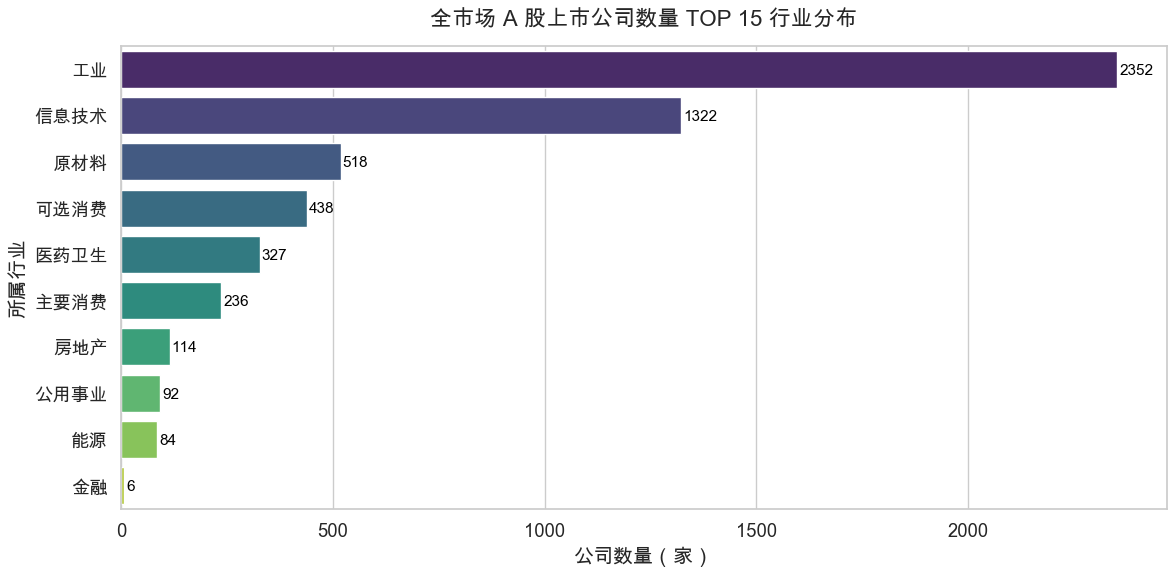


=== 三大交易所上市公司核心行业结构对比 ===
📸 饼图已保存: output/5_三大交易所行业分布饼图.png


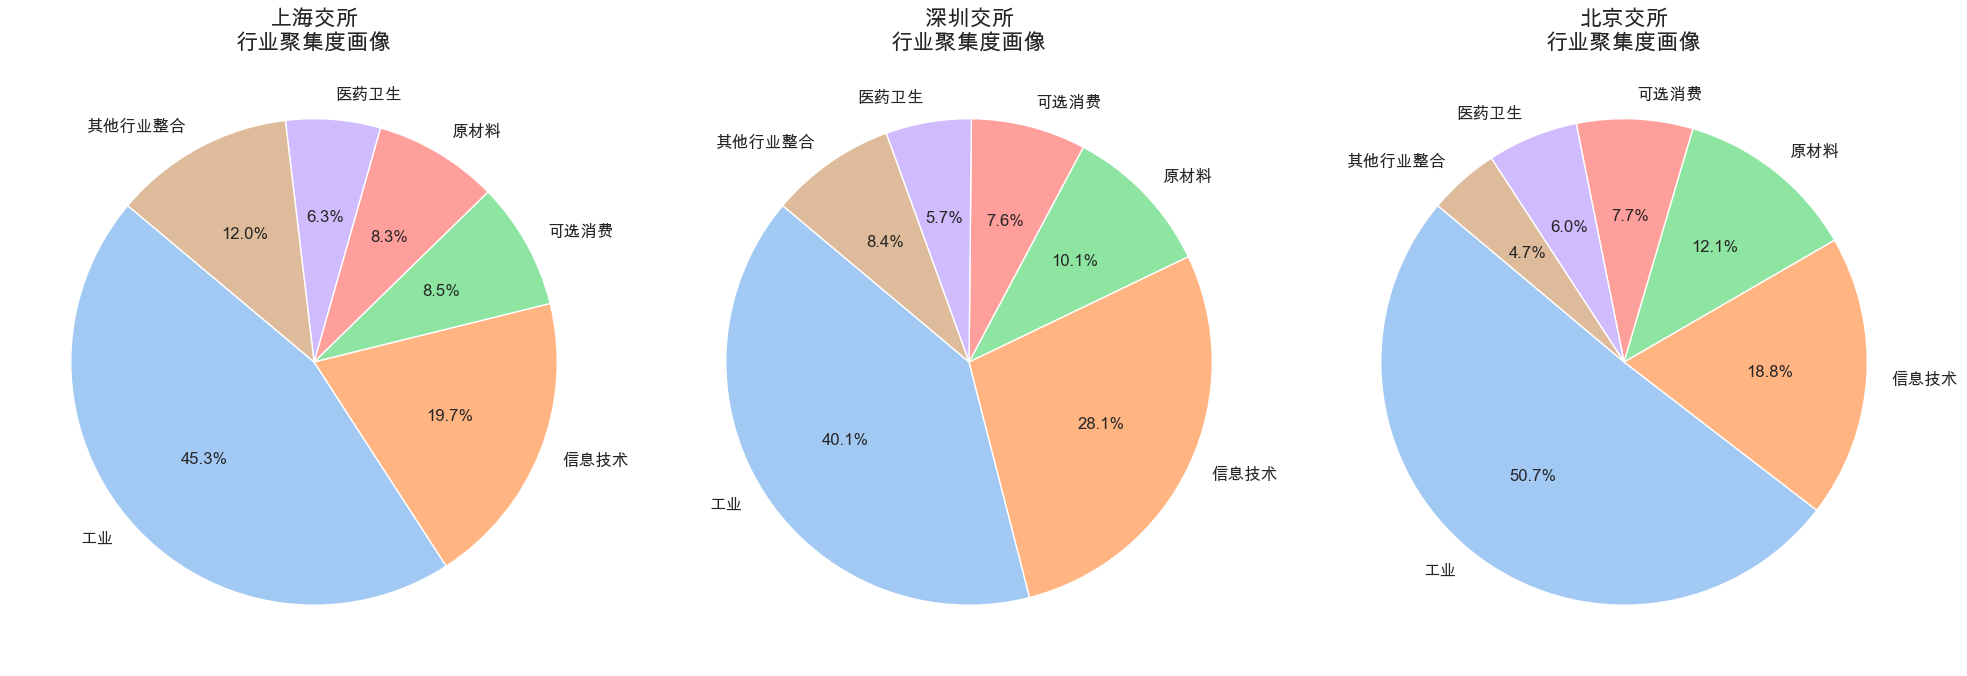

In [ ]:
# --- 1. 整体市场行业 TOP 15 条形图 ---
top_industries = df['所属行业'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_industries.values, y=top_industries.index, hue=top_industries.index, palette="viridis", legend=False)
plt.title('全市场 A 股上市公司数量 TOP 15 行业分布', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('公司数量（家）')
plt.ylabel('所属行业')
for i, v in enumerate(top_industries.values):
    plt.text(v + 5, i + 0.1, str(v), color='black', fontsize=11)
plt.tight_layout()

# --- 保存条形图 ---
out_path_bar = os.path.join("output", "4_全市场行业分布TOP15条形图.png")
plt.savefig(out_path_bar, dpi=300, bbox_inches='tight')
print(f"📸 条形图已保存: {out_path_bar}")

plt.show()

# --- 2. 各交易所最新行业分布 TOP 5 饼图 ---
print("\n=== 三大交易所上市公司核心行业结构对比 ===")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
exchanges = ['上海证券交易所', '深圳证券交易所', '北京证券交易所']
colors = sns.color_palette('pastel')[0:10]

for i, exchange in enumerate(exchanges):
    ex_df = df[df['交易所名称'] == exchange]
    
    # 提取前 5 大行业，其余归为“其他”以保证饼图整洁
    top5_ind = ex_df['所属行业'].value_counts().head(5)
    other_count = ex_df['所属行业'].value_counts()[5:].sum()
    if other_count > 0:
        top5_ind['其他行业整合'] = other_count
        
    axes[i].pie(top5_ind.values, labels=top5_ind.index, autopct='%1.1f%%', 
                startangle=140, colors=colors, textprops={'fontsize': 12})
    axes[i].set_title(f'{exchange[:2]}交所\n行业聚集度画像', fontsize=16, fontweight='bold')

plt.tight_layout()

# --- 保存饼图 ---
out_path_pie = os.path.join("output", "5_三大交易所行业分布饼图.png")
plt.savefig(out_path_pie, dpi=300, bbox_inches='tight')
print(f"📸 饼图已保存: {out_path_pie}")

plt.show()

#### 📝 分析结论：三大交易所的差异化竞争格局
通过饼图的横向对比，我们可以发现三大交易所呈现出明显的行业偏好与错位发展：
* **上交所**：具有较强的综合性与“硬科技”属性（受科创板带动），不仅有传统的装备制造，其在计算机通信等高科技设备制造上的比例也非常大。
* **深交所**：电子设备制造、软件信息服务占比极高。由于创业板的存在，深交所汇聚了中国最为活跃的互联网、IT 与创新消费类企业。
* **北交所**：作为服务创新型中小企业的主阵地，其“专用设备制造业”和“通用设备制造业”占比远超沪深，高度贴合国家扶持“专精特新”小巨人的战略定位。

## 📝 项目总结与宏观洞察

基于本项目构建的自动化数据清洗管道，我们对中国 A 股全市场 5400 余家上市公司的全景数据进行了深度的探索性分析（EDA），得出以下四个核心宏观洞察：

### 1. 政策周期是 A 股扩容的绝对“指挥棒”
通过将历史 IPO 数量与重大政策节点叠加，我们清晰地看到中国资本市场的发展与制度改革高度共振。无论是 2009 年创业板开市，还是 2019-2021 年科创板、北交所相继落地带来的注册制红利，都直接造就了陡峭的上市高峰；而 2013 年前后的长停发期则在图表上留下了显著的断层。数据证明，**制度创新是激发市场活力的最核心引擎**。

### 2. 多层次资本市场呈现完美的“阶梯式新老交替”
上市年龄结构分析揭示了各板块截然不同的“历史厚度”：
* **沪深主板**：作为市场的压舱石，沉淀了大量上市超 15-20 年的老牌企业，底蕴深厚。
* **创业板**：历经十余年发展，目前主力集中在 5-15 年区间，是市场成熟的“中坚力量”。
* **科创板与北证**：分布极度集中在 0-5 年区间，作为“新鲜血液”，它们没有历史包袱，拉低了市场的整体年龄中位数，充分体现了资本市场对硬科技和创新型中小企业的精准滴灌。

### 3. “硬科技”与“高端制造”已成 A 股绝对基石
通过对上百种细分行业进行机构级标准降维后，我们发现“工业”（含各类装备制造、航天军工等）与“信息技术”（含半导体、软件开发等）已成为当前 A 股容纳企业数量最大的两个超级池子。这标志着 A 股市场的基本盘已经完成“脱虚向实”，深度契合了国家向高端制造业转型和发展新质生产力的宏观战略。

### 4. 三大交易所实现了清晰的“错位发展与差异化定位”
横向对比三大交易所的行业聚集度画像：
* **上交所**：大盘蓝筹与科创属性并重，工业与信息技术双轮驱动，综合实力强劲。
* **深交所**：受创业板带动，具有极强的“新经济”色彩，信息技术（IT与互联网相关）及可选消费企业占比极高。
* **北交所**：高度聚焦“专精特新”小巨人，**工业类企业占比呈现压倒性优势**，与其他两大交易所形成了极其完美的错位竞争互补格局。

---
**💡 项目结语**：
本项目不仅成功利用 Python 自动化脚本代替了对传统商业数据库的依赖，实现了从“网页杂乱数据”到“机构级标准数据”的升华，更通过多维度的可视化分析，清晰勾勒出了一幅中国资本市场“体量倍增、结构优化、多层次并进”的恢弘历史画卷。